**Load dataset**

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import BaseEstimator, TransformerMixin

In [57]:

# STEP 1: LOAD & SORT DATA (Chronological Order)

df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')
df = df.sort_values(by='Date').reset_index(drop=True)


# STEP 2: TIME-BASED TRAIN-TEST SPLIT (Prevents Lookahead Leakage)

train_df = df[df['Year'] < 2024].copy()
test_df = df[df['Year'] >= 2024].copy()

# Define feature groups and target variable
num_cols = ['Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']
cat_cols = ['Region', 'Model', 'Source_Type']
target_col = 'Estimated_Deliveries'

**EDA**

--- Starting EDA ---


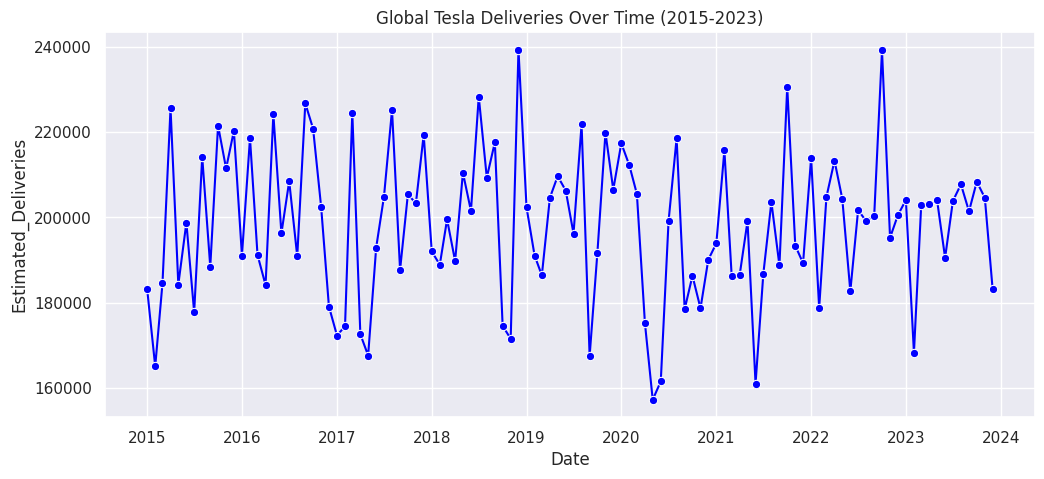

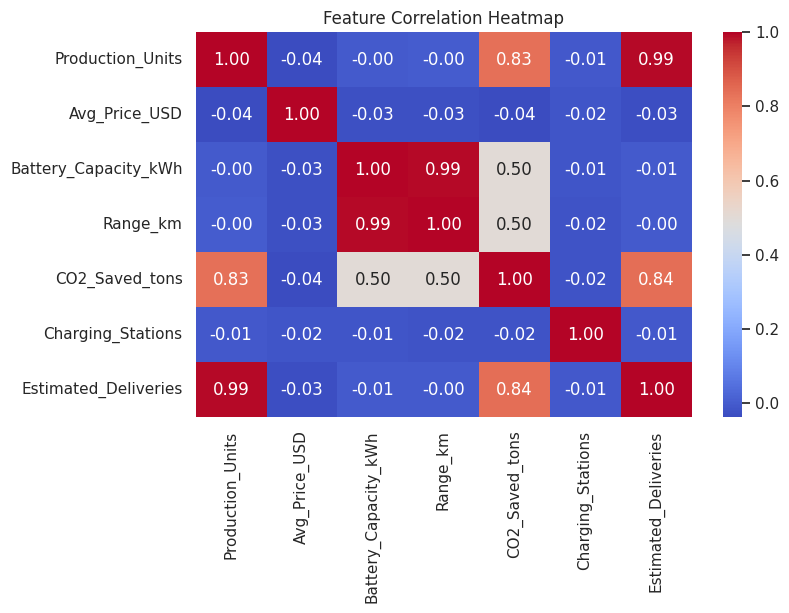

--- EDA Complete ---


In [58]:
print("--- Starting EDA ---")
sns.set_theme(style="darkgrid")

# Visualizing Global Deliveries Trend Over Time
plt.figure(figsize=(12, 5))
global_trend = train_df.groupby('Date')[target_col].sum().reset_index()
sns.lineplot(data=global_trend, x='Date', y=target_col, marker='o', color='blue')
plt.title('Global Tesla Deliveries Over Time (2015-2023)')
plt.show()

# Heatmap to check correlations between numerical features and target
plt.figure(figsize=(8, 5))
sns.heatmap(train_df[num_cols + [target_col]].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

print("--- EDA Complete ---")


**CUSTOM TIME-SERIES FEATURE ENGINEERING TRANSFORMER**

In [59]:
class TimeSeriesFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, target_col='Estimated_Deliveries', lag_months=[1, 2, 3], rolling_windows=[3]):
        self.target_col = target_col
        self.lag_months = lag_months
        self.rolling_windows = rolling_windows

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df_out = X.copy()

        # Calendar & Cyclical Features
        df_out['Quarter'] = df_out['Date'].dt.quarter
        df_out['Month_sin'] = np.sin(2 * np.pi * df_out['Month'] / 12)
        df_out['Month_cos'] = np.cos(2 * np.pi * df_out['Month'] / 12)

        # Sort values to ensure grouped lags map to chronological order
        df_out = df_out.sort_values(by=['Region', 'Model', 'Date']).reset_index(drop=True)

        # Creating Historical Lag Features
        for lag in self.lag_months:
            df_out[f'Target_Lag_{lag}'] = df_out.groupby(['Region', 'Model'])[self.target_col].shift(lag)
            df_out[f'Prod_Lag_{lag}'] = df_out.groupby(['Region', 'Model'])['Production_Units'].shift(lag)

        # Creating Rolling Window Features
        for window in self.rolling_windows:
            df_out[f'Target_Rolling_Mean_{window}'] = (
                df_out.groupby(['Region', 'Model'])[self.target_col]
                .transform(lambda x: x.shift(1).rolling(window=window).mean())
            )

        # Clean missing values introduced by the shifting / rolling windows
        df_out = df_out.bfill().fillna(0)
        return df_out

# Instantiate and apply Feature Engineering to DataFrames
engineer = TimeSeriesFeatureEngineer(target_col='Estimated_Deliveries', lag_months=[1, 2, 3], rolling_windows=[3])
train_engineered = engineer.transform(train_df)
test_engineered = engineer.transform(test_df)

# Dynamic collection of the newly engineered column names
new_features = [col for col in train_engineered.columns if col not in train_df.columns]

print("\n--- Sample of train_engineered with new features ---")
print(train_engineered.head())
print("\n--- Sample of test_engineered with new features ---")
print(test_engineered.head())


--- Sample of train_engineered with new features ---
   Year  Month Region       Model  Estimated_Deliveries  Production_Units  \
0  2015      1   Asia  Cybertruck                 11325             11887   
1  2015      2   Asia  Cybertruck                 13254             14878   
2  2015      3   Asia  Cybertruck                 10257             11441   
3  2015      4   Asia  Cybertruck                 15221             15951   
4  2015      5   Asia  Cybertruck                  6406              7281   

   Avg_Price_USD  Battery_Capacity_kWh  Range_km  CO2_Saved_tons  ... Quarter  \
0       54449.08                    60       339          575.88  ...       1   
1       88864.06                    75       432          858.86  ...       1   
2       65107.47                   100       581          893.90  ...       1   
3      112686.63                    60       341          778.55  ...       2   
4      107577.61                    75       448          430.48  ...       2 

**PREPROCESSING AND REGRESSION MODELING**

In [60]:
updated_num_cols = num_cols + [col for col in new_features if col not in ['Quarter', 'Month_sin', 'Month_cos']]
passthrough_cols = ['Month_sin', 'Month_cos', 'Quarter']
all_feature_cols = updated_num_cols + cat_cols + passthrough_cols

# Isolate features (X) and target labels (y)
X_train = train_engineered[all_feature_cols]
y_train = train_engineered[target_col]

X_test = test_engineered[all_feature_cols]
y_test = test_engineered[target_col]

# Define Pipeline Sub-components for scaling and encoding
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, drop='first'))
])

# Map transformers to their column selections
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, updated_num_cols),
        ('cat', categorical_pipeline, cat_cols),
        ('pass', 'passthrough', passthrough_cols)
    ]
)

# Build the final comprehensive modeling pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Fit the pipeline on training data
full_pipeline.fit(X_train, y_train)
print("Pipeline Training Successfully Executed!")

# Helper function to calculate RMSE, addressing potential scikit-learn version incompatibility
def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Display the pipeline diagram
from sklearn import set_config
set_config(display='diagram')
display(full_pipeline)

Pipeline Training Successfully Executed!


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Production_Units',
                                                   'Avg_Price_USD',
                                                   'Battery_Capacity_kWh',
                                                   'Range_km', 'CO2_Saved_tons',
                                                   'Charging_Stations',
                                                   'Target_Lag_1', 'Prod_Lag_1',
                                                   'Target_Lag_2', 'Prod_Lag_2',
                                                   'Target_Lag_3', 'Prod_Lag_3',
                                                   'Target_Rolling_Mean_3']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  ['Region', 'Model',
                                                   'Source_Type']),
                                                 ('pass', 'passthrough',
                                                  ['Month_sin', 'Month_cos',
                                                   'Quarter'])])),
                ('regressor', LinearRegression())])

In [61]:
y_train_pred = full_pipeline.predict(X_train)
y_test_pred = full_pipeline.predict(X_test)

print("\n=== Training Metrics (2015-2023) ===")
print(f"MAE:  {mean_absolute_error(y_train, y_train_pred):.2f}")
print(f"RMSE: {calculate_rmse(y_train, y_train_pred):.2f}") # Use the helper function
print(f"R²:    {r2_score(y_train, y_train_pred):.4f}")

print("\n=== Test Forecasting Metrics (2024-2025) ===")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred):.2f}")
print(f"RMSE: {calculate_rmse(y_test, y_test_pred):.2f}") # Use the helper function
print(f"R²:    {r2_score(y_test, y_test_pred):.4f}")


=== Training Metrics (2015-2023) ===
MAE:  311.53
RMSE: 383.63
R²:    0.9907

=== Test Forecasting Metrics (2024-2025) ===
MAE:  323.29
RMSE: 394.03
R²:    0.9888


### Visualizing the Best Fit Line for Linear Regression

Let's visualize how well the Linear Regression model's predictions align with the actual data for both the training and test sets. A scatter plot with a diagonal line (y=x) helps to understand the model's performance: points close to the diagonal indicate accurate predictions.

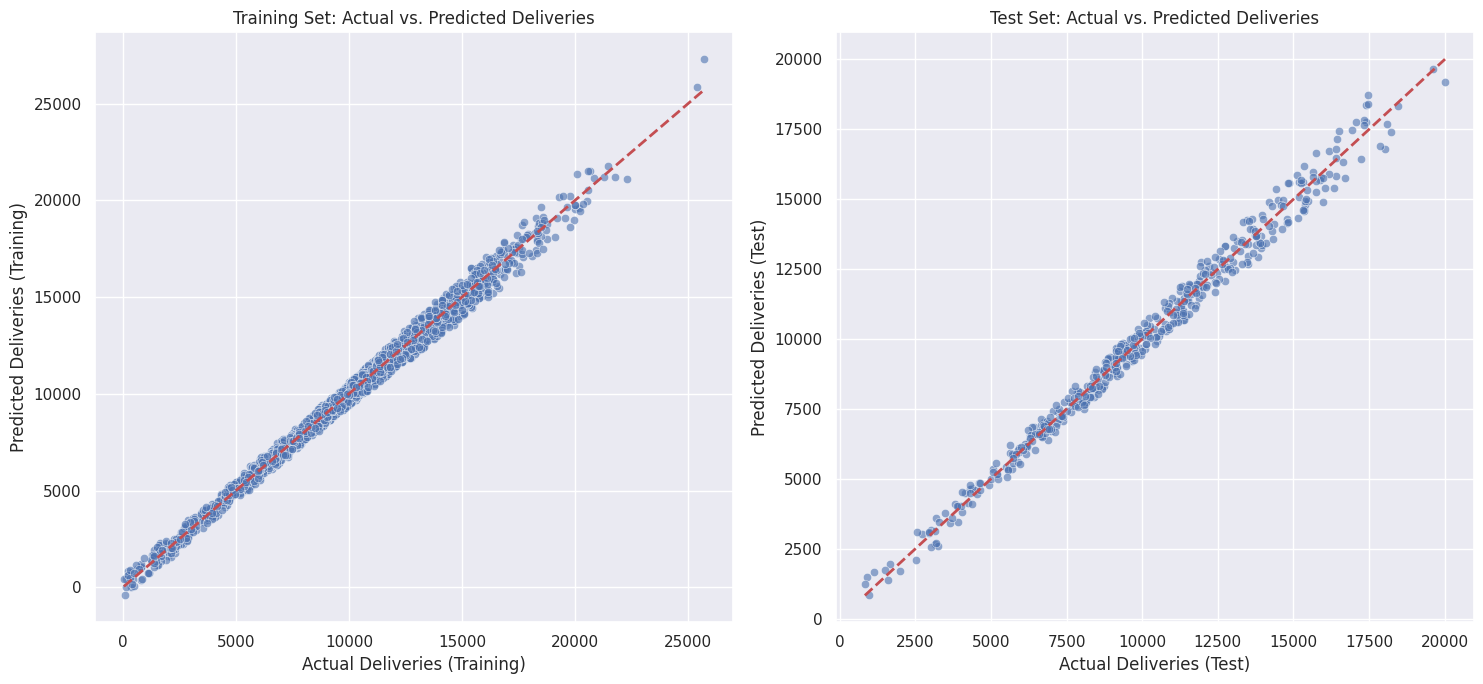

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))

# Plot for Training Data
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.scatterplot(x=y_train, y=y_train_pred, alpha=0.6)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.title('Training Set: Actual vs. Predicted Deliveries')
plt.xlabel('Actual Deliveries (Training)')
plt.ylabel('Predicted Deliveries (Training)')
plt.grid(True)

# Plot for Test Data
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Test Set: Actual vs. Predicted Deliveries')
plt.xlabel('Actual Deliveries (Test)')
plt.ylabel('Predicted Deliveries (Test)')
plt.grid(True)

plt.tight_layout()
plt.show()

**Hyperparameter tuning**

In [63]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Create a new pipeline specifically for hyperparameter tuning with Ridge
# We'll reuse the 'preprocessor' from the previous cell.
tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge()) # Using Ridge for tuning
])

# Define the parameter grid for Ridge regression's alpha
param_grid = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

# Use TimeSeriesSplit for cross-validation to prevent data leakage
# n_splits determines the number of splits (folds) to make.
# For example, n_splits=5 will create 5 training/test set pairs.
tscv = TimeSeriesSplit(n_splits=5)

print("Starting hyperparameter tuning with GridSearchCV using TimeSeriesSplit...")
# Create and fit GridSearchCV object
grid_search = GridSearchCV(tuning_pipeline, param_grid, cv=tscv, scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("\n--- Hyperparameter Tuning Complete ---")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score (negative MSE): {-grid_search.best_score_:.2f}") # Convert back to positive MSE for display

# Get the best model from the grid search
best_tuned_model = grid_search.best_estimator_

# Make predictions with the best model on the training and test set
y_train_pred_tuned = best_tuned_model.predict(X_train)
y_test_pred_tuned = best_tuned_model.predict(X_test)

print("\n=== Tuned Model Training Metrics (2015-2023) ===")
print(f"MAE:  {mean_absolute_error(y_train, y_train_pred_tuned):.2f}")
print(f"RMSE: {calculate_rmse(y_train, y_train_pred_tuned):.2f}")
print(f"R²:    {r2_score(y_train, y_train_pred_tuned):.4f}")

print("\n=== Tuned Model Test Forecasting Metrics (2024-2025) ===")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred_tuned):.2f}")
print(f"RMSE: {calculate_rmse(y_test, y_test_pred_tuned):.2f}")
print(f"R²:    {r2_score(y_test, y_test_pred_tuned):.4f}")

Starting hyperparameter tuning with GridSearchCV using TimeSeriesSplit...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

--- Hyperparameter Tuning Complete ---
Best parameters found: {'regressor__alpha': 0.01}
Best cross-validation score (negative MSE): nan

=== Tuned Model Training Metrics (2015-2023) ===
MAE:  311.53
RMSE: 383.63
R²:    0.9907

=== Tuned Model Test Forecasting Metrics (2024-2025) ===
MAE:  323.28
RMSE: 394.03
R²:    0.9888


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan]
  warnings.warn(


**Time Series Forecasting.**

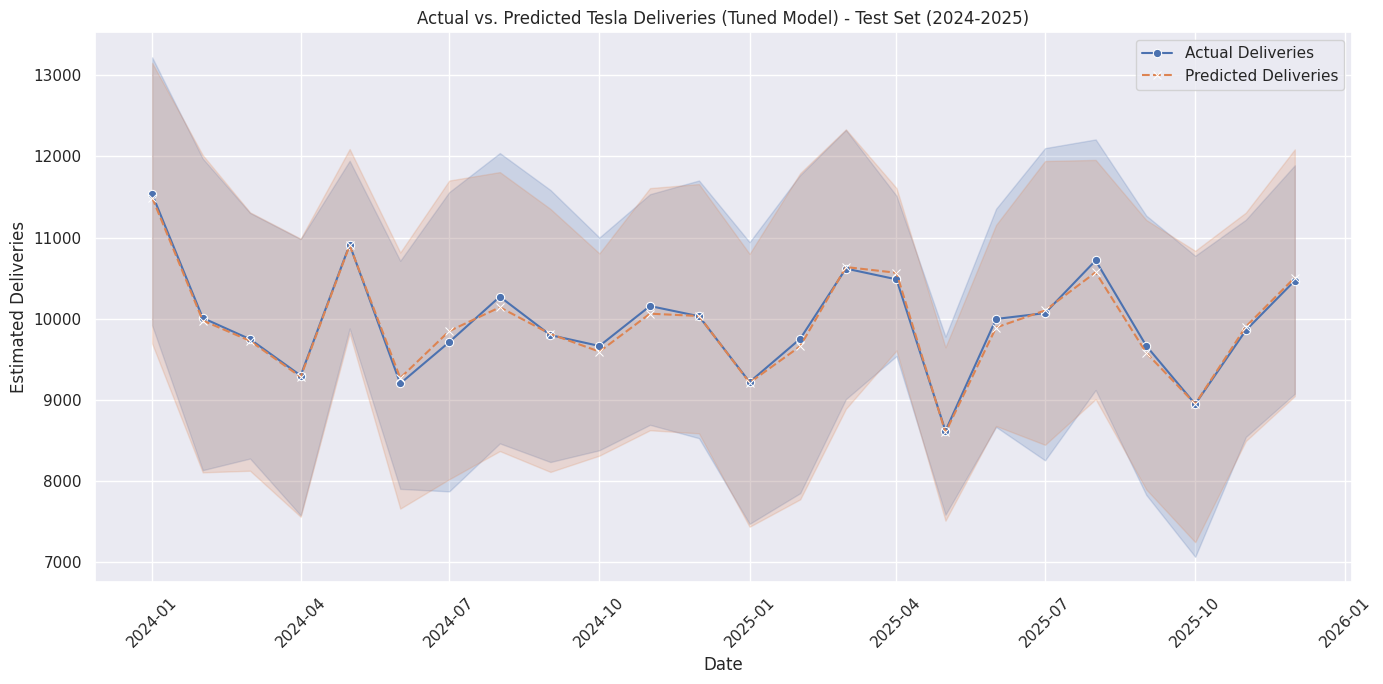

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for plotting actual vs. predicted
# Use test_engineered['Date'] to align indices with y_test and y_test_pred_tuned
forecast_df = pd.DataFrame({
    'Date': test_engineered['Date'],
    'Actual_Deliveries': y_test,
    'Predicted_Deliveries': y_test_pred_tuned
}).sort_values(by='Date')

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Actual_Deliveries', data=forecast_df, label='Actual Deliveries', marker='o')
sns.lineplot(x='Date', y='Predicted_Deliveries', data=forecast_df, label='Predicted Deliveries', linestyle='--', marker='x')
plt.title('Actual vs. Predicted Tesla Deliveries (Tuned Model) - Test Set (2024-2025)')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()